In [13]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from torchvision.transforms import v2

# Import de ton architecture locale
from models.dinov2 import DinoV2, DinoV2Config, DinoV2ADE20K

# Détection du matériel (MPS pour puce M1/M2)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Périphérique utilisé : {device}")

# Variables globales à modifier
CHEMIN_IMAGE = "rue.jpg" 
CHEMIN_POIDS = "best_dinov2_ade20k.pth"
RESOLUTION = 518

Périphérique utilisé : mps


In [14]:
def create_ade20k_palette():
    """Génère une palette de couleurs fixes pour les 150 classes d'ADE20K"""
    np.random.seed(42)
    palette = np.random.randint(0, 255, size=(150, 3), dtype=np.uint8)
    return palette

palette = create_ade20k_palette()

In [15]:
# Pipeline pour l'inférence du modèle
transform_model = v2.Compose([
    v2.Resize(size=RESOLUTION, antialias=True),
    v2.CenterCrop(size=(RESOLUTION, RESOLUTION)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Pipeline pour l'affichage brut
transform_display = v2.Compose([
    v2.Resize(size=RESOLUTION, antialias=True),
    v2.CenterCrop(size=(RESOLUTION, RESOLUTION)),
])

# Chargement
img_raw = Image.open(CHEMIN_IMAGE).convert('RGB')
img_display = transform_display(img_raw)
input_tensor = transform_model(img_raw).unsqueeze(0).to(device)

print(f"Dimension du tenseur d'entrée : {input_tensor.shape}")

Dimension du tenseur d'entrée : torch.Size([1, 3, 518, 518])


In [16]:
config = DinoV2Config(name="S")
backbone = DinoV2(config=config, image_size=RESOLUTION, patch_size=14)
model = DinoV2ADE20K(backbone=backbone, num_classes=150)

# Chargement sécurisé avec map_location
model.load_state_dict(torch.load(CHEMIN_POIDS, map_location=device, weights_only=True))
model = model.to(device).eval()

print("Modèle chargé avec succès.")

Modèle chargé avec succès.


In [18]:
with torch.no_grad():
    logits = model(input_tensor)
    predicted_mask = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()

# Colorisation via la palette
color_mask = palette[predicted_mask]
print(f"Dimension du masque prédit : {predicted_mask.shape}")

Dimension du masque prédit : (518, 518)


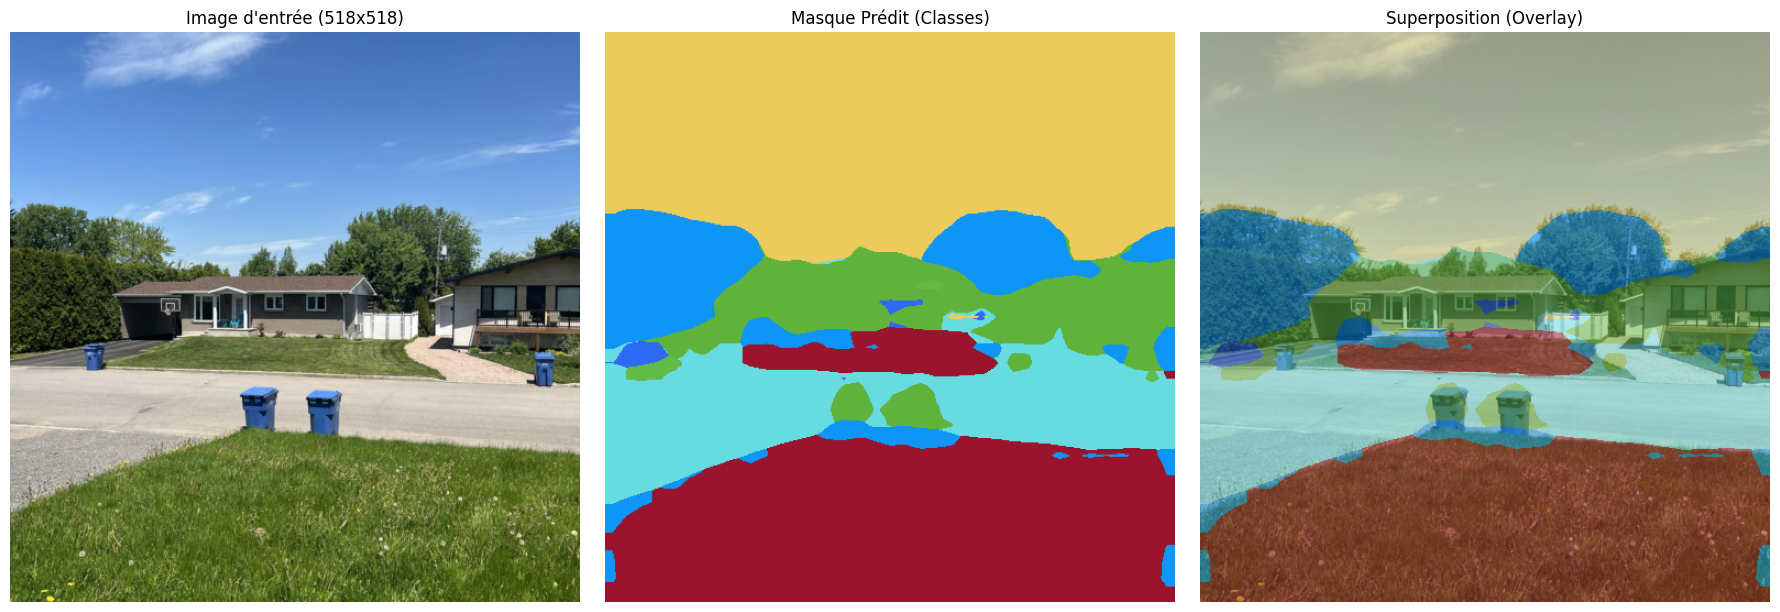

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Image originale
axes[0].imshow(img_display)
axes[0].set_title("Image d'entrée (518x518)")
axes[0].axis("off")

# Masque colorisé
axes[1].imshow(color_mask)
axes[1].set_title("Masque Prédit (Classes)")
axes[1].axis("off")

# Superposition (Overlay)
axes[2].imshow(img_display)
axes[2].imshow(color_mask, alpha=0.5)
axes[2].set_title("Superposition (Overlay)")
axes[2].axis("off")

plt.tight_layout()
plt.show()